<a href="https://colab.research.google.com/github/d12eek/ANN-And-DL-Lab-24mcs005/blob/main/MLP_model_for_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
torch.__version__

'2.6.0+cu124'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import make_regression
from sklearn import metrics
from sklearn import decomposition
from sklearn import manifold
from tqdm.notebook import trange, tqdm

#TensorFlow and Keras Libraries
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras import Model
from torchvision import transforms
from tensorflow.keras.utils import to_categorical
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# Hiding the warnings
import warnings
warnings.filterwarnings('ignore')


In [ ]:
file_path = '/content/Housing.csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.shape

(545, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
num_col = []
cat_col = []
for i in df.columns:
  if df[i].dtype == 'object':
    cat_col.append(i)
  else:
    num_col.append(i)

In [ ]:
num_col

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

In [ ]:
cat_col

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'furnishingstatus']

In [ ]:
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
cat_cols_present = [col for col in cat_cols if col in df.columns]


for col in cat_cols_present:
    df = pd.get_dummies(df, columns=[col], prefix=[col], drop_first=True)

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

In [ ]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
print("Training set : X => ",train_X.shape)
print("Training set : y => ",train_y.shape)

print("Testing set : X => ",test_X.shape)
print("Testing set : y => ",test_y.shape)

Training set : X =>  (381, 13)
Training set : y =>  (381,)
Testing set : X =>  (164, 13)
Testing set : y =>  (164,)


In [ ]:
bins = [0, 5000000, 10000000, np.inf]
labels = [0, 1, 2]

# Bin the price column
train_y_cat = pd.cut(train_y, bins=bins, labels=labels)
test_y_cat = pd.cut(test_y, bins=bins, labels=labels)

# Convert to one-hot encoding
train_y_encoded = tf.keras.utils.to_categorical(train_y_cat)
test_y_encoded = tf.keras.utils.to_categorical(test_y_cat)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

In [ ]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(train_X_scaled.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.fit(train_X_scaled, train_y_encoded, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5533 - loss: 0.9977 - val_accuracy: 0.7792 - val_loss: 0.6857
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8160 - loss: 0.6291 - val_accuracy: 0.8961 - val_loss: 0.5053
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8571 - loss: 0.4353 - val_accuracy: 0.8831 - val_loss: 0.4528
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8806 - loss: 0.3733 - val_accuracy: 0.8831 - val_loss: 0.4309
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8887 - loss: 0.3104 - val_accuracy: 0.8961 - val_loss: 0.4318
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8874 - loss: 0.3063 - val_accuracy: 0.8831 - val_loss: 0.4222
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9059 - loss: 0.2738 - val_accuracy: 0.8831 - val_loss: 0.4184
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8928 - loss: 0.2808 - val_accuracy: 0.8831 - v

In [ ]:
loss, accuracy = model.evaluate(test_X_scaled, test_y_encoded)
print('Test accuracy:', accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7907 - loss: 0.5189
Test accuracy: 0.792682945728302


In [ ]:
predictions = model.predict(test_X_scaled)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_y_encoded, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


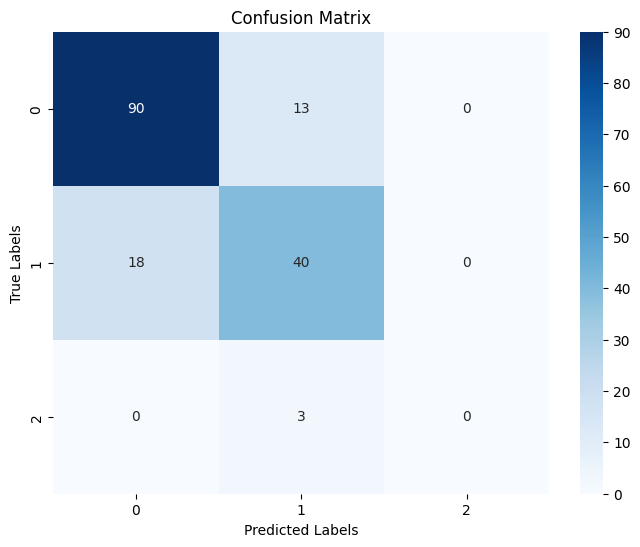

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
# Generate and print the classification report
class_report = classification_report(true_labels, predicted_labels)
print("Classification Report:\n", class_report)

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       103
           1       0.71      0.69      0.70        58
           2       0.00      0.00      0.00         3

    accuracy                           0.79       164
   macro avg       0.52      0.52      0.52       164
weighted avg       0.78      0.79      0.78       164

